In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns # স্ট্যাটিস্টিক্যাল ভিজুয়ালাইজেশনের জন্য (এখানে সরাসরি ব্যবহার না হলেও রাখা)।

In [ ]:
#X represents the size of a tumor in centimeters.
X = np.array([3.78, 2.44, 2.09, 0.14, 1.72, 1.65, 4.92, 4.37, 4.96, 4.52, 3.69, 5.88]).reshape(-1,1)

#Note: X has to be reshaped into a column from a row for the LogisticRegression() function to work.
#y represents whether or not the tumor is cancerous (0 for "No", 1 for "Yes").
y = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

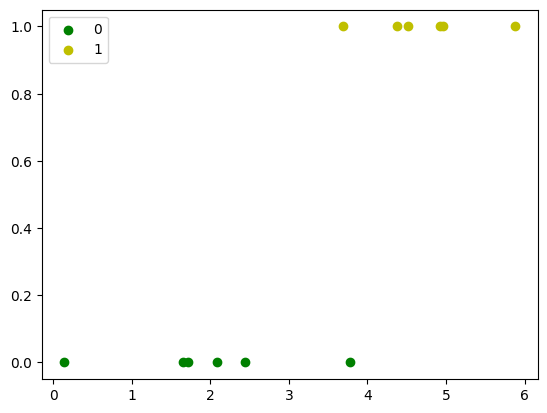

In [ ]:
plt.scatter(X[y == 0],y[y==0], color='g', label='0') # X[y == 0] → যেখানে y=0 (নন-ক্যান্সার), সেই X মানগুলো।
plt.scatter(X[y == 1],y[y==1], color='y', label='1') # y[y==0] → সব 0 হবে, তাই সব পয়েন্ট y=0 লাইনে থাকবে।
plt.legend(); # রঙ: green = non-cancer, yellow = cancer।
plt.show()

In [ ]:
def sigmoid(z): # সিগময়েড ফাংশন আউটপুট 0 থেকে 1-এর মধ্যে আনে।
    return 1 / (1 + np.exp(-z)) # লজিস্টিক রিগ্রেশনের মূল ফাংশন।

In [ ]:
# গ্রেডিয়েন্ট ডিসেন্ট ইমপ্লিমেন্টেশন
m, n = X.shape # ডাটা পয়েন্টের সংখ্যা (12), n = ফিচারের সংখ্যা (1)।
w1 = 0 # ওয়েট ও বায়াস (শূন্য দিয়ে শুরু)।
w0 = 0
lr=0.01 # লার্নিং রেট।
epochs=100 #  কতবার প্যারামিটার আপডেট হবে
w1_history = []
w0_history = [] # প্রতিটি epoch-এর জন্য মান সংরক্ষণ করবে।
cost_history = []  # store cost values

for _ in range(epochs):
  # Forward pass
      z = X*w1 + w0  # z = লিনিয়ার কম্বিনেশন, তারপর sigmoid দিয়ে প্রেডিকশন y_hat
      y_hat = sigmoid(z)
      # Compute cost (add epsilon to avoid log(0))
      epsilon = 1e-15 #  log(0) এড়াতে ছোট মান যোগ করা

      # লস ফাংশন (বাইনারি ক্রস-এন্ট্রপি)।
      # epsilon → log(0) এড়াতে ছোট মান যোগ করা।
      cost = -(1 / m) * np.sum(
          y * np.log(y_hat + epsilon) +
          (1 - y) * np.log(1 - y_hat + epsilon)
       )


      # Gradients
      # গ্রেডিয়েন্ট ক্যালকুলেশন (চেইন রুল অনুসারে)।
      dw1 = np.dot(X.T, (y_hat - y))
      dw0 = (1 / m) * np.sum(y_hat - y)

      # Update parameters
      # প্যারামিটার আপডেট (গ্রেডিয়েন্ট ডিসেন্ট)।
      w1 -= lr * dw1
      w0 -= lr * dw0

      # ইতিহাস সংরক্ষণ (প্লট করার জন্য)।
      w1_history.append(w1.mean())
      w0_history.append(w0)
      cost_history.append(cost)


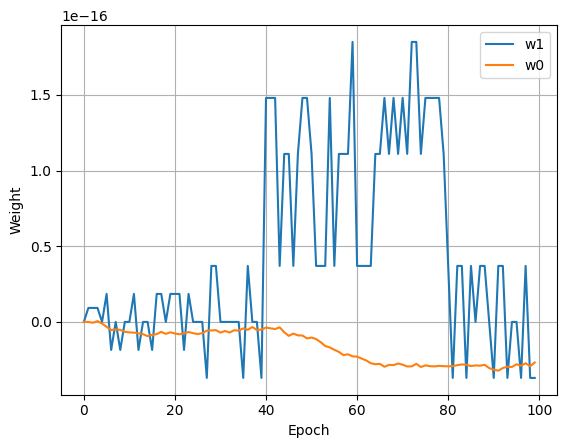

In [ ]:
# লসের পরিবর্তন প্লট
plt.plot(w1_history)
plt.plot(w0_history)
plt.xlabel('Epoch')
plt.ylabel('Weight')
plt.legend(['w1', 'w0'])
plt.grid()
plt.show()

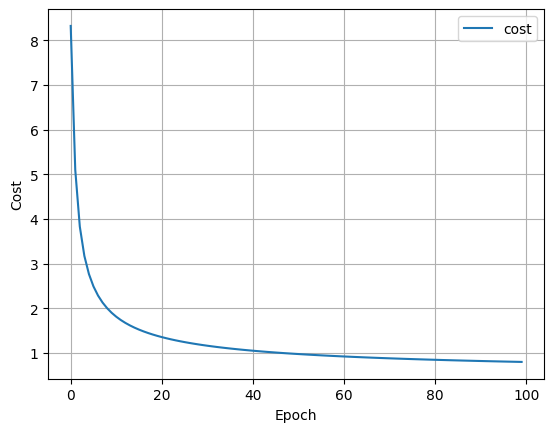

In [ ]:
plt.plot(cost_history)
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid()
plt.legend(['cost'])
plt.show()



In [ ]:
# প্রেডিকশন আউটপুট
print(X) # X প্রিন্ট করে।
z = w1 * X + w0 # ফাইনাল w1, w0 দিয়ে z বের করে, তারপর sigmoid দিয়ে y_pred (প্রোবাবিলিটি)।
y_pred =sigmoid(z) # y_pred এর মান 0.5 এর কাছাকাছি (কারণ এখনো ভালো শেখেনি)।
print(y_pred)
print(y)

[[3.78]
 [2.44]
 [2.09]
 [0.14]
 [1.72]
 [1.65]
 [4.92]
 [4.37]
 [4.96]
 [4.52]
 [3.69]
 [5.88]]
[[0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]]
[0 0 0 0 0 0 1 1 1 1 1 1]


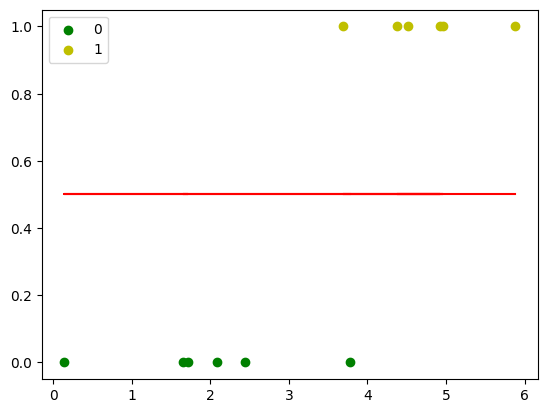

In [ ]:
# ডাটা ও প্রেডিকশন একসাথে প্লট

plt.scatter(X[y == 0],y[y==0], color='g', label='0')
plt.scatter(X[y == 1],y[y==1], color='y', label='1')
plt.plot(X, y_pred, color='r')
plt.legend();
plt.show()

# plt.plot(X, y_pred, color='r') → প্রেডিক্টেড প্রোবাবিলিটি লাইন (S-শেপ হওয়ার কথা, কিন্তু এখানে প্রায় সোজা, কারণ শেখা হয়নি)।

